In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def get_relaxation_time(f, t):
    tau = np.interp(1 / np.e, f[::-1], t[::-1])
    if not np.min(f) < 1 / np.e:
        return np.nan
    return tau

def get_diffusion_coeff(m, t, dim=2, scale=1):
    mask = t < t.max() / (10 * scale)
    c = np.mean(np.log10(m) - np.log10(t))
    return (10 ** c) / (2 * dim)

def nan_argmax(f):
    fc = f.copy()
    fc[np.isnan(f)] = np.min(f[~np.isnan(f)])
    return np.argmax(fc)

In [5]:
dp_data = np.load('data/dp-dynamics-data-3-longer-2.npz', allow_pickle=True)
ga_data = np.load('data/ga-dynamics-data-4.npz', allow_pickle=True)
ga_density_data = np.load('data/ga-densities.npz', allow_pickle=True)
ga_jam_data = np.load('data/ga-jam-2d.npz', allow_pickle=True)
sphere_data = np.load('data/sphere-dynamics-data-3.npz', allow_pickle=True)

def get_ga_conversion(ga_density_data, mu, alpha, nv):
    mask = (ga_density_data['nv'] == nv) & (ga_density_data['mu'] == mu) & (ga_density_data['alpha'] == alpha)
    return (ga_density_data['true_phi'] / ga_density_data['phi'])[mask][0]

ga_data_true_phi = np.array([get_ga_conversion(ga_density_data, mu, alpha, nv) * phi for mu, alpha, nv, phi in zip(
    ga_data['mu'], ga_data['alpha'], ga_data['nv'], ga_data['phi']
)])

ga_jam_data_true_phi = np.array([get_ga_conversion(ga_density_data, mu, alpha, nv) * phi for mu, alpha, nv, phi in zip(
    ga_jam_data['mu'], ga_jam_data['alpha'], ga_jam_data['nv'], ga_jam_data['phi']
)])

ga_min_save_decade = 1_000
dp_min_save_decade = 1_000
sphere_min_save_decade_map = {
    '1': 1_000,
    '2': 100,
    '3': 10,
}
sphere_min_save_decade = np.array([sphere_min_save_decade_map[str(w).split('_')[-1]] for w in sphere_data['which']])

# GA Jamming Data

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_7326/3267139286.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([mu] * len(phis), phis, s=1, c=cmap(alpha_norm(alpha)))


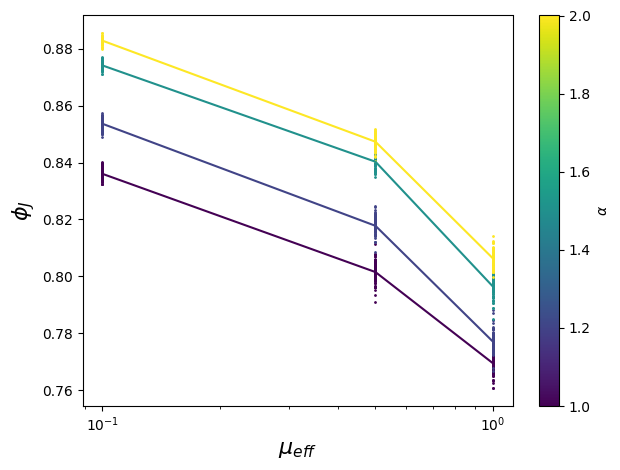

In [6]:
alpha_norm = plt.Normalize(min(ga_data['alpha']), max(ga_data['alpha']))
cmap = plt.cm.viridis

for alpha in np.unique(ga_data['alpha']):
    x, y = [], []
    for mu in np.unique(ga_data['mu']):

        ga_jam_data_mask = (ga_jam_data['mu'] == mu) & (ga_jam_data['alpha'] == alpha)
        phis = ga_jam_data_true_phi[ga_jam_data_mask]
        plt.scatter([mu] * len(phis), phis, s=1, c=cmap(alpha_norm(alpha)))
        
        x.append(mu)
        y.append(np.mean(phis))
    
    plt.plot(x, y, c=cmap(alpha_norm(alpha)))
plt.xscale('log')
plt.xlabel(r'$\mu_{eff}$', fontsize=16)
plt.ylabel(r'$\phi_J$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
sm.set_array(np.unique(ga_data['alpha']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\alpha$')

plt.tight_layout()
plt.savefig('figures/ga/phi-j.png', dpi=600)

# GA Dynamics Data

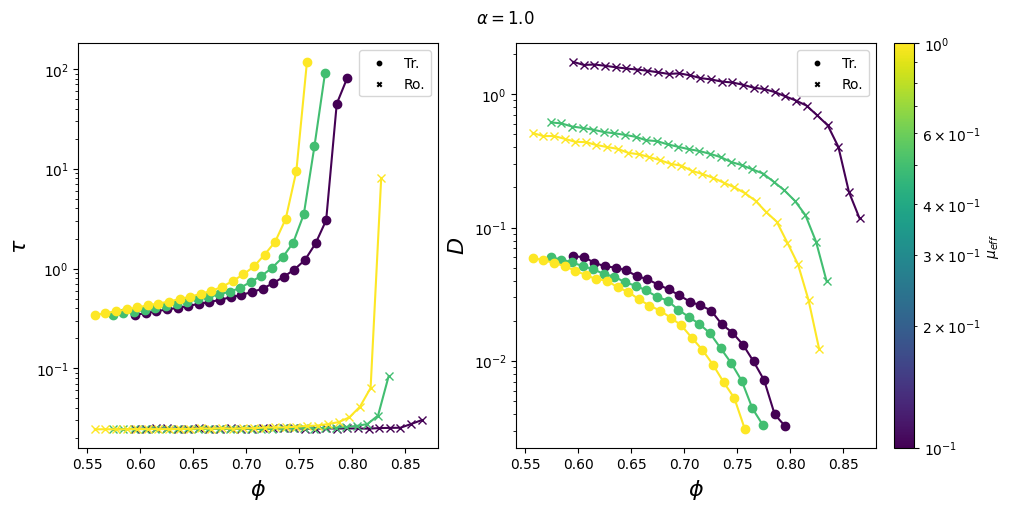

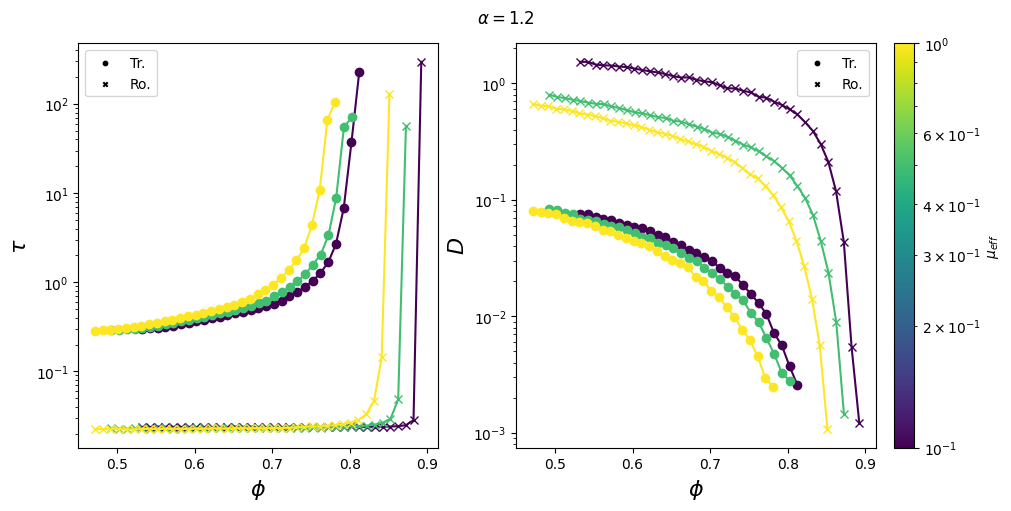

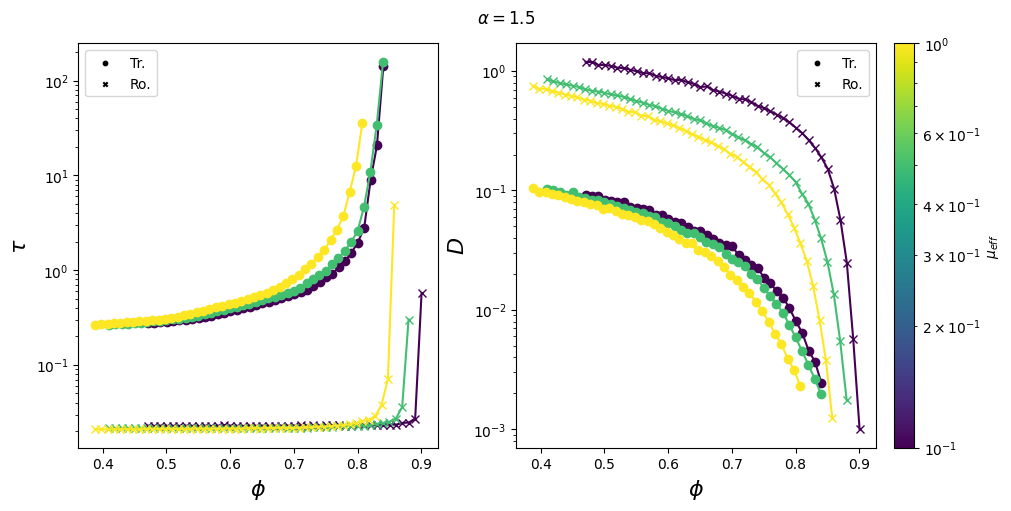

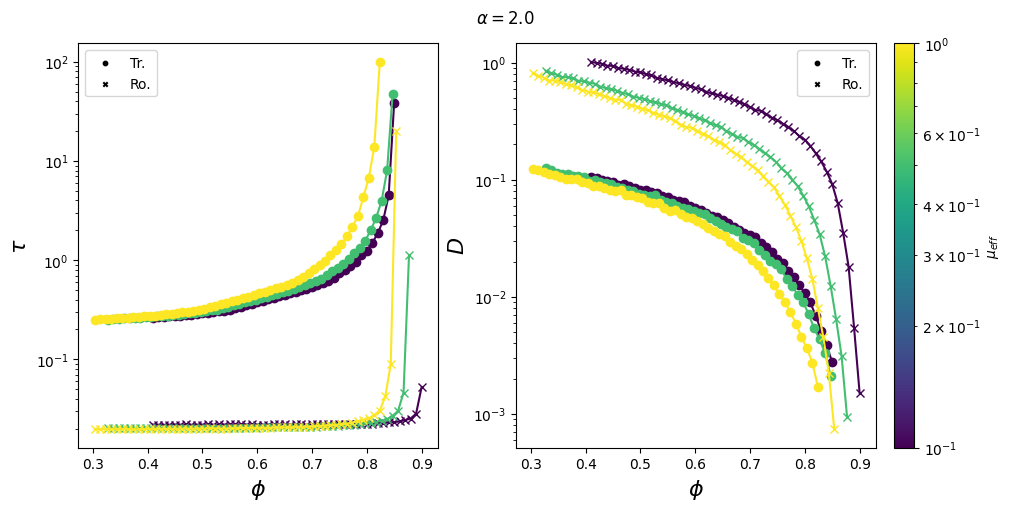

In [72]:
ga_tau = np.array([get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(ga_data['isf_small'], ga_data['t'], ga_data['temp'])])
ga_D = np.array([get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(ga_data['msd_small'], ga_data['t'], ga_data['temp'])])
ga_D[np.isnan(ga_tau)] = np.nan

ga_tau_R = np.array([get_relaxation_time(aisf, t * np.sqrt(temp)) for aisf, t, temp in zip(ga_data['aisf_small'], ga_data['t'], ga_data['temp'])])
ga_D_R = np.array([get_diffusion_coeff(msad, t * np.sqrt(temp)) for msad, t, temp in zip(ga_data['msad_small'], ga_data['t'], ga_data['temp'])])
ga_D_R[np.isnan(ga_tau_R)] = np.nan

alpha_norm = plt.Normalize(min(ga_data['alpha']), max(ga_data['alpha']))
mu_norm = LogNorm(min(ga_data['mu']), max(ga_data['mu']))
cmap = plt.cm.viridis

for alpha in np.unique(ga_data['alpha']):
    fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))
    for mu in np.unique(ga_data['mu']):
        ga_data_mask = (ga_data['mu'] == mu) & (ga_data['alpha'] == alpha)
        x = ga_data['phi'][ga_data_mask]
        order = np.argsort(x)
        x = x[order]
        ax[0].plot(x, ga_tau[ga_data_mask][order], c=cmap(mu_norm(mu)), marker='o')
        ax[0].plot(x, ga_tau_R[ga_data_mask][order], c=cmap(mu_norm(mu)), marker='x')
        ax[1].plot(x, ga_D[ga_data_mask][order], c=cmap(mu_norm(mu)), marker='o')
        ax[1].plot(x, ga_D_R[ga_data_mask][order], c=cmap(mu_norm(mu)), marker='x')
    for a in ax:
        a.set_yscale('log')
        a.set_xlabel(r'$\phi$', fontsize=16)
        a.scatter([], [], marker='o', label='Tr.', c='k', s=10)
        a.scatter([], [], marker='x', label='Ro.', c='k', s=10)
        a.legend()
        
    ax[0].set_ylabel(r'$\tau$', fontsize=16)
    ax[1].set_ylabel(r'$D$', fontsize=16)

    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(np.unique(ga_data['mu']))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')

    plt.suptitle(fr'$\alpha=${alpha}')
    plt.savefig(f'figures/dynamics/ga-alpha-{alpha}-dynamics.png', dpi=600)
    plt.show()

# Disk Dynamics

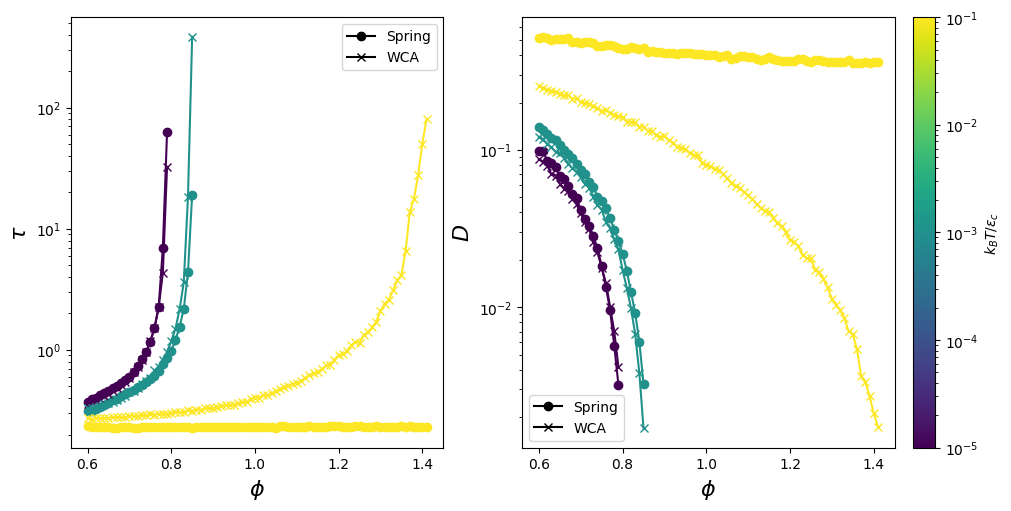

In [75]:
sphere_tau = np.array([get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp, min_save_decade in zip(sphere_data['isf'], sphere_data['t'], sphere_data['temp'], sphere_min_save_decade)])
sphere_D = np.array([get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp, min_save_decade in zip(sphere_data['msd'], sphere_data['t'], sphere_data['temp'], sphere_min_save_decade)])
sphere_D[np.isnan(sphere_tau)] = np.nan

temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        phi_0 = sphere_data['phi'][mask]
        x = sphere_data['phi'][mask]
        order = np.argsort(x)
        x = x[order]
        ax[0].plot(x, sphere_tau[mask][order], c=cmap(temp_norm(temp)), marker=marker)
        ax[1].plot(x, sphere_D[mask][order], c=cmap(temp_norm(temp)), marker=marker)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
    a.plot([], [], c='k', marker='o', label='Spring')
    a.plot([], [], c='k', marker='x', label='WCA')
    a.legend()

ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

plt.savefig('figures/dynamics/disk.png', dpi=600)
plt.show()

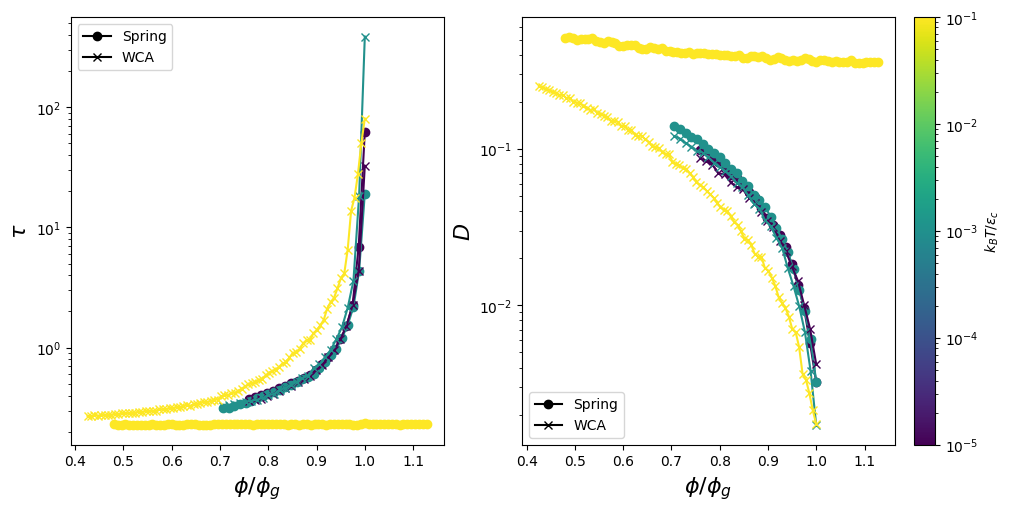

In [111]:
temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        if not np.any(mask):
            continue
        phi_0 = sphere_data['phi'][mask]
        x = sphere_data['phi'][mask]
        order = np.argsort(x)
        x = x[order]

        i = nan_argmax(sphere_tau[mask][order])
        ax[0].plot(x / x[i], sphere_tau[mask][order], c=cmap(temp_norm(temp)), marker=marker)
        
        ax[1].plot(x / x[i], sphere_D[mask][order], c=cmap(temp_norm(temp)), marker=marker)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi / \phi_g$', fontsize=16)
    a.plot([], [], c='k', marker='o', label='Spring')
    a.plot([], [], c='k', marker='x', label='WCA')
    a.legend()

ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

plt.savefig('figures/dynamics/disk-scaled.png', dpi=600)
plt.show()

# Disk Dynamics with True Density

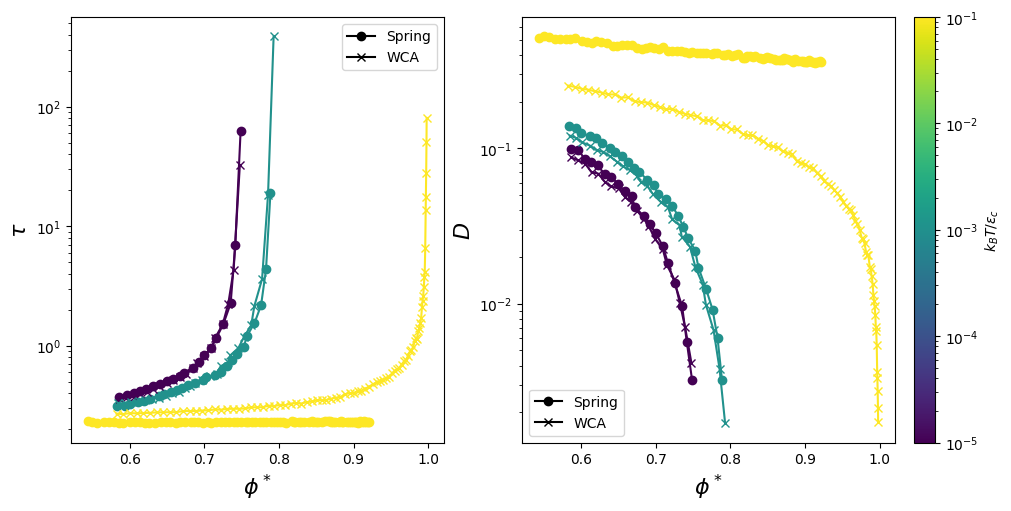

In [107]:
temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        x = sphere_data['phi_true'][mask]
        order = np.argsort(x)
        x = x[order]
        ax[0].plot(x, sphere_tau[mask][order], c=cmap(temp_norm(temp)), marker=marker)
        ax[1].plot(x, sphere_D[mask][order], c=cmap(temp_norm(temp)), marker=marker)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi^*$', fontsize=16)
    a.plot([], [], c='k', marker='o', label='Spring')
    a.plot([], [], c='k', marker='x', label='WCA')
    a.legend()
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

plt.savefig('figures/dynamics/disk-true-density.png', dpi=600)
plt.show()

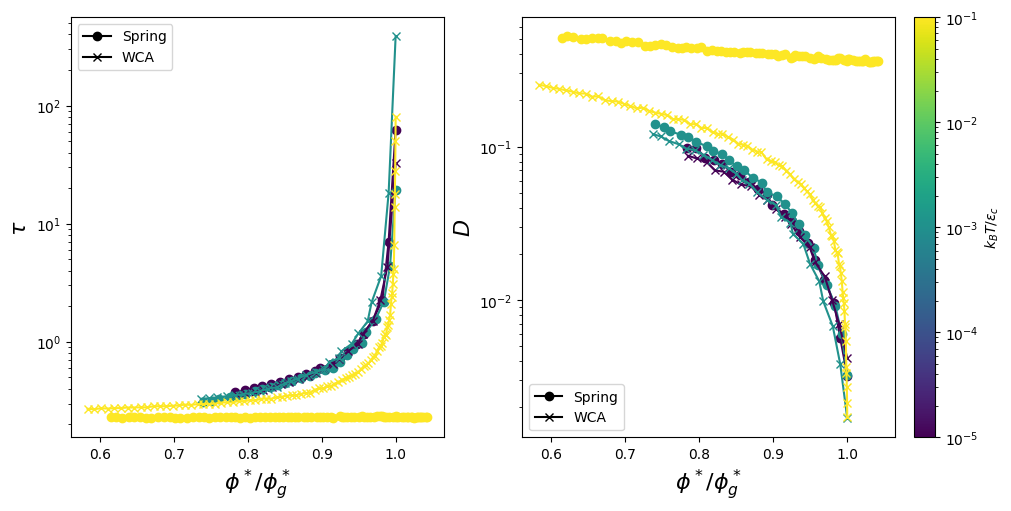

In [112]:
temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        if not np.any(mask):
            continue
        x = sphere_data['phi_true'][mask]
        order = np.argsort(x)
        x = x[order]

        i = nan_argmax(sphere_tau[mask][order])
        ax[0].plot(x / x[i], sphere_tau[mask][order], c=cmap(temp_norm(temp)), marker=marker)
        
        ax[1].plot(x / x[i], sphere_D[mask][order], c=cmap(temp_norm(temp)), marker=marker)

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi^* / \phi^*_g$', fontsize=16)
    a.plot([], [], c='k', marker='o', label='Spring')
    a.plot([], [], c='k', marker='x', label='WCA')
    a.legend()
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

plt.savefig('figures/dynamics/disk-true-density-scaled.png', dpi=600)
plt.show()

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_7326/118561153.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(1 - sphere_data['phi_true'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_7326/118561153.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(1 - sphere_data['phi_true'][mask], sphere_D[mas

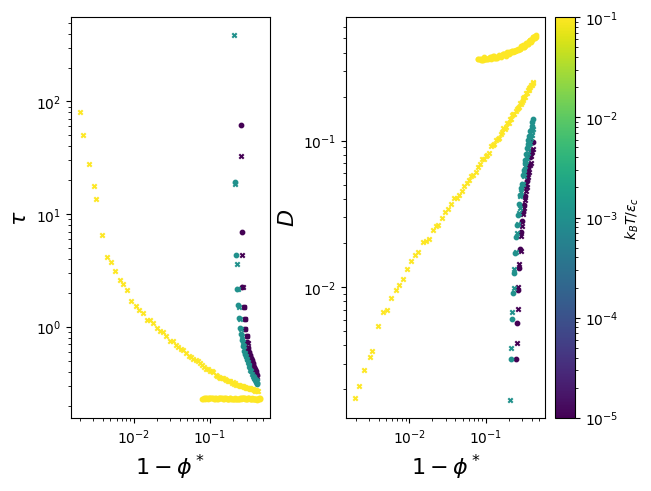

In [15]:
temp_norm = LogNorm(min(sphere_data['temp']), max(sphere_data['temp']))
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True)

for which in np.unique(sphere_data['which']):
    marker = 'x' if 'wca' in which else 'o'
    for temp in np.unique(sphere_data['temp']):
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        ax[0].scatter(1 - sphere_data['phi_true'][mask], sphere_tau[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)
        ax[1].scatter(1 - sphere_data['phi_true'][mask], sphere_D[mask], c=cmap(temp_norm(temp)), marker=marker, s=10)

for a in ax:
    a.set_yscale('log')
    a.set_xscale('log')
    a.set_xlabel(r'$1-\phi^*$', fontsize=16)
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=temp_norm, cmap=cmap)
sm.set_array(np.unique(sphere_data['temp']))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$k_B T/ \varepsilon_c$')

# Plotting GA and Disks Together

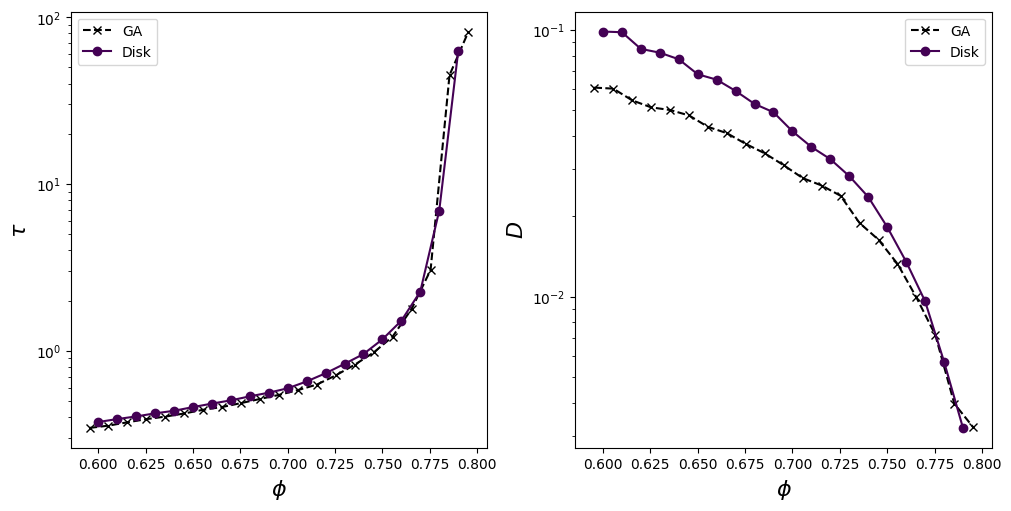

In [68]:
fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

ga_data_mask = (ga_data['mu'] == 0.1) & (ga_data['alpha'] == 1.0)
x = ga_data['phi'][ga_data_mask]
order = np.argsort(x)
x = x[order]
y = ga_tau[ga_data_mask][order]
ax[0].plot(x, y, c='k', marker='x', ls='--', label='GA')
y = ga_D[ga_data_mask][order]
ax[1].plot(x, y, c='k', marker='x', ls='--', label='GA')

for which in np.unique(sphere_data['which']):
    if 'wca' in which:
        continue
    for temp in np.unique(sphere_data['temp']):
        if temp != 1e-5:
            continue
        mask = (sphere_data['which'] == which) & (sphere_data['temp'] == temp)
        x = sphere_data['phi'][mask]
        order = np.argsort(x)
        x = x[order]
        y = sphere_tau[mask][order]
        ax[0].plot(x, y, c=cmap(temp_norm(temp)), marker='o', label='Disk')
        y = sphere_D[mask][order]
        ax[1].plot(x, y, c=cmap(temp_norm(temp)), marker='o', label='Disk')
        break
    break

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
    a.legend()
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

plt.savefig('figures/dynamics/ga-sphere-comparison.png', dpi=600)
plt.show()

# DP Dynamics

In [51]:
dp_tau = np.array([get_relaxation_time(isf, t * np.sqrt(temp)) for isf, t, temp in zip(dp_data['isf_small'], dp_data['t'], dp_data['temp'])])
dp_D = np.array([get_diffusion_coeff(msd, t * np.sqrt(temp)) for msd, t, temp in zip(dp_data['msd_small'], dp_data['t'], dp_data['temp'])])
dp_D[np.isnan(dp_tau)] = np.nan

dp_tau_v = np.array([get_relaxation_time(isf_v, t * np.sqrt(temp)) for isf_v, t, temp in zip(dp_data['isf_vertex_small'], dp_data['t'], dp_data['temp'])])
dp_D_v = np.array([get_diffusion_coeff(msd_v, t * np.sqrt(temp)) for msd_v, t, temp in zip(dp_data['msd_vertex_small'], dp_data['t'], dp_data['temp'])])
dp_D_v[np.isnan(dp_tau_v)] = np.nan

eb = dp_data['eb'].copy()
eb = np.array([e if e else 0 for e in eb])

eb_norm = LogNorm(min(eb[eb > 0]), max(eb[eb > 0]))
cmap = plt.cm.viridis

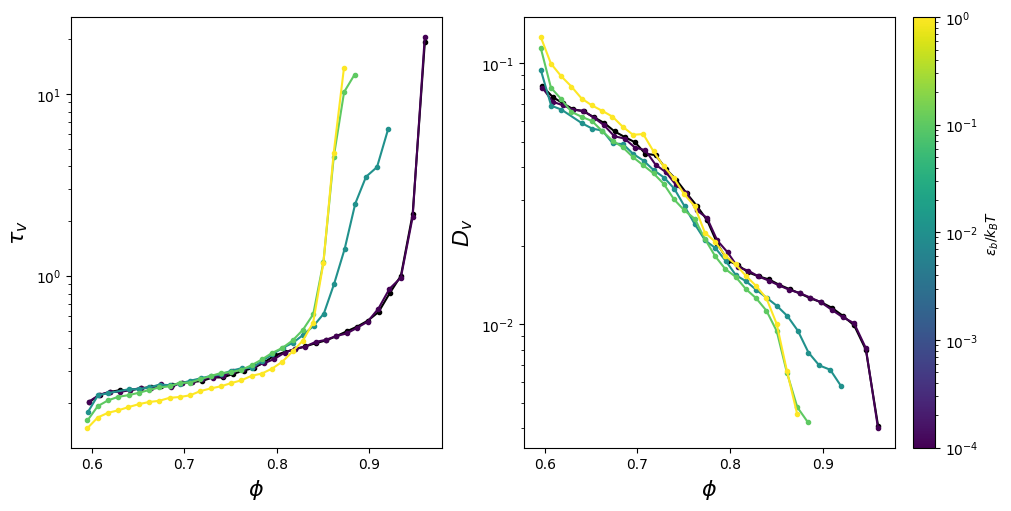

In [55]:
fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

eb_norm = LogNorm(min(eb[eb > 0]), max(eb[eb > 0]))
cmap = plt.cm.viridis

for _eb in np.unique(eb):
    dp_mask = eb == _eb

    if _eb > 0:
        c = cmap(eb_norm(_eb))
    else:
        c = 'k'

    x = dp_data['phi_true'][dp_mask]
    order = np.argsort(x)
    x = x[order]
    y = dp_tau_v[dp_mask][order]
    ax[0].plot(x, y, c=c, markersize=3, marker='o')
    y = dp_D_v[dp_mask][order]
    ax[1].plot(x, y, c=c, markersize=3, marker='o')

for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
    
ax[0].set_ylabel(r'$\tau_v$', fontsize=16)
ax[1].set_ylabel(r'$D_v$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=eb_norm, cmap=cmap)
sm.set_array(np.unique(_eb))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\varepsilon_b / k_B T$')

plt.savefig('figures/dynamics/dp-vertex-dynamics.png', dpi=600)
plt.show()

# Plotting GA and DP Together

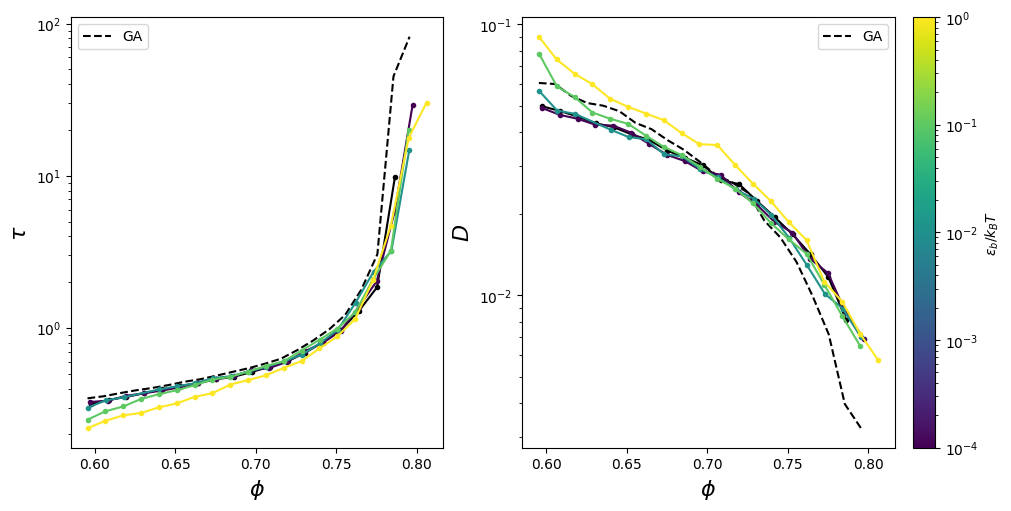

In [116]:
ga_data_mask = (ga_data['alpha'] == 1.0) & (ga_data['mu'] == 0.1)

fig, ax = plt.subplots(1, 2, sharex=True, constrained_layout=True, figsize=(10, 5))

x = ga_data['phi'][ga_data_mask]
order = np.argsort(x)
y = ga_tau[ga_data_mask][order]
x = x[order]
ax[0].plot(x, y, c='k', label='GA', ls='--')
y = ga_D[ga_data_mask][order]
ax[1].plot(x, y, c='k', label='GA', ls='--')

eb_norm = LogNorm(min(eb[eb > 0]), max(eb[eb > 0]))
cmap = plt.cm.viridis

for _eb in np.unique(eb):
    dp_mask = eb == _eb

    if _eb > 0:
        c = cmap(eb_norm(_eb))
    else:
        c = 'k'

    x = dp_data['phi_true'][dp_mask]
    order = np.argsort(x)
    x = x[order]
    y = dp_tau[dp_mask][order]
    ax[0].plot(x, y, c=c, markersize=3, marker='o')
    y = dp_D[dp_mask][order]
    ax[1].plot(x, y, c=c, markersize=3, marker='o')


for a in ax:
    a.set_yscale('log')
    a.set_xlabel(r'$\phi$', fontsize=16)
    a.legend()
    
ax[0].set_ylabel(r'$\tau$', fontsize=16)
ax[1].set_ylabel(r'$D$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=eb_norm, cmap=cmap)
sm.set_array(np.unique(_eb))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\varepsilon_b / k_B T$')

plt.savefig('figures/dynamics/dp-ga-comparison.png', dpi=600)
plt.show()

# Disk Berthier Diagrams